# Extraction de connaissances à partir de données structurées et non structurées

## Séance 4 : Analyse Factorielle des Correspondances Simples (AFC)

### Utilisation de `python`

## Librairies utilisées

Données accidents aux Etats-Unis sur la période 1973-1978 [à télécharger](USAccDeaths.csv)

In [1]:
import pandas
import numpy
import matplotlib.pyplot as plt
import seaborn
seaborn.set_style("white")

from prince import CA

## Données utilisées

In [2]:
df = pandas.read_csv("USAccDeaths.csv", index_col = "Year")
df.columns.rename("Month", inplace = True)
df.index.rename("Year", inplace = True)
df

Month,January,February,March,April,May,June,July,August,September,October,November,December
Year,,,,,,,,,,,,
1973,9007,8106,8928,9137,10017,10826,11317,10744,9713,9938,9161,8927
1974,7750,6981,8038,8422,8714,9512,10120,9823,8743,9129,8710,8680
1975,8162,7306,8124,7870,9387,9556,10093,9620,8285,8466,8160,8034
1976,7717,7461,7767,7925,8623,8945,10078,9179,8037,8488,7874,8647
1977,7792,6957,7726,8106,8890,9299,10625,9302,8314,8850,8265,8796
1978,7836,6892,7791,8192,9115,9434,10484,9827,9110,9070,8633,9240


## Calcul de AFC

In [3]:
ca = CA(n_components = 5) # minimum du nombre de modalités - 1
ca.fit(df)

## Valeurs propres

In [4]:
ca.eigenvalues_

array([3.76283456e-04, 1.85670084e-04, 7.57831853e-05, 3.76894447e-05,
       2.45791383e-05])

In [5]:
ca.total_inertia_

np.float64(0.0007000053078490678)

In [6]:
ca.percentage_of_variance_

array([53.75437181, 26.52409655, 10.82608723,  5.38416556,  3.51127885])

In [7]:
eig = pandas.DataFrame(
    { 
        "Dimension" : ["Dim" + str(x + 1) for x in range(5)],
        "% variance expliquée": numpy.round(ca.percentage_of_variance_, 4),
        "% variance expliquée cumulée": numpy.round(numpy.cumsum(ca.percentage_of_variance_), 4),
    }
)
eig

,Dimension,% variance expliquée,% variance expliquée cumulée
0,Dim1,53.7544,53.7544
1,Dim2,26.5241,80.2785
2,Dim3,10.8261,91.1046
3,Dim4,5.3842,96.4887
4,Dim5,3.5113,100.0000


## Choix des facteurs

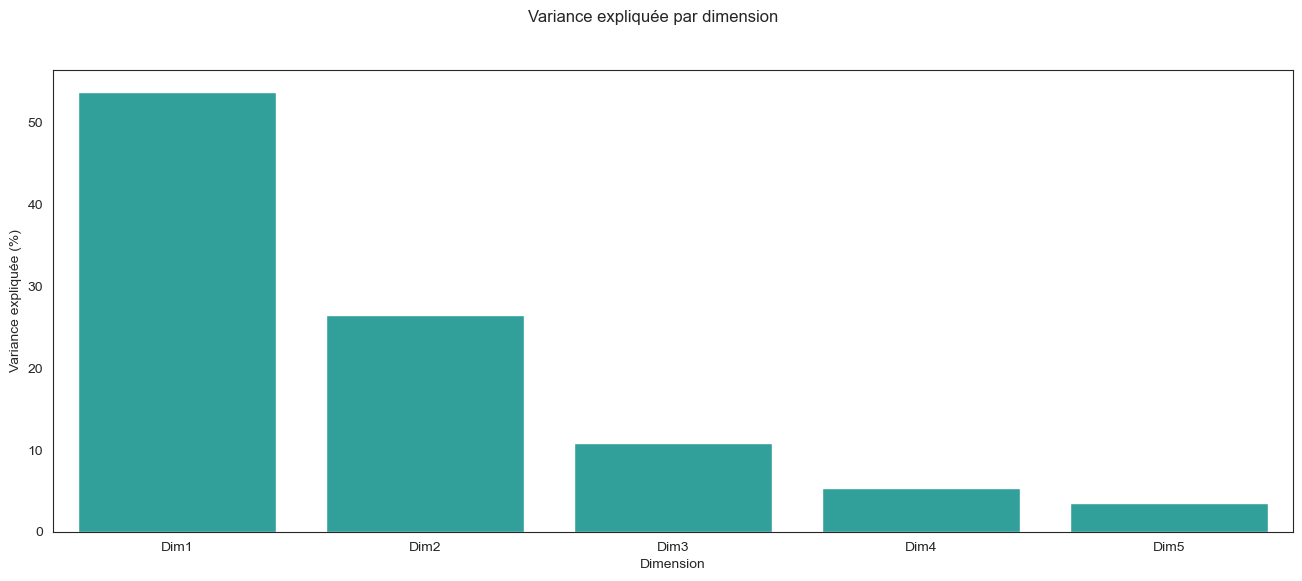

In [8]:
plt.figure(figsize=(16, 6))
g_eig = seaborn.barplot(x = "Dimension", 
                        y = "% variance expliquée",
                        color = "lightseagreen",
                        data = eig)
g_eig.set(ylabel = "Variance expliquée (%)")
g_eig.figure.suptitle("Variance expliquée par dimension")

plt.show()

## Représentation des lignes

In [9]:
df_row = pandas.DataFrame(ca.row_coordinates(df)).rename(columns = {0: "Dim1", 1: "Dim2"})
df_row

,Dim1,Dim2,2,3,4
Year,,,,,
1973,0.017407,-0.013220,0.004260,0.004290,0.006992
1974,-0.013806,-0.014447,0.011227,-0.001709,-0.006420
1975,0.030026,-0.000779,-0.009876,-0.003899,-0.005081
1976,0.003461,0.024649,0.009397,-0.004836,0.002169
1977,-0.011677,0.010810,-0.004949,0.011591,-0.002571
1978,-0.026633,-0.004477,-0.010296,-0.005888,0.004086


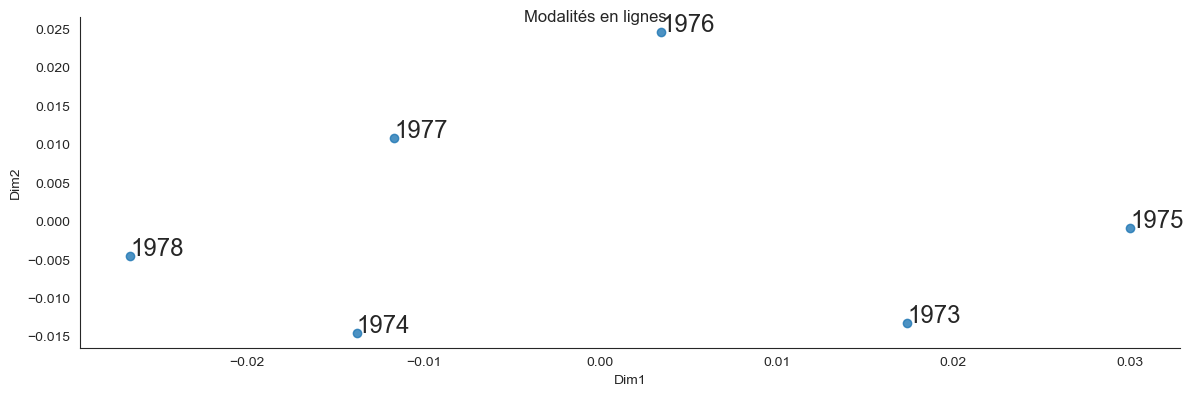

In [10]:
g_row = seaborn.lmplot(x = "Dim1", y = "Dim2", data = df_row, fit_reg = False, 
                       height = 4, aspect = 3)
g_row.fig.suptitle("Modalités en lignes")
for i in df_row.index:
    plt.text(df_row.loc[i].Dim1, df_row.loc[i].Dim2, i, size = "xx-large")
plt.show()

## Représentation des colonnes

In [11]:
df_col = pandas.DataFrame(ca.column_coordinates(df)).rename(columns = {0: "Dim1", 1: "Dim2"})
df_col

,Dim1,Dim2,2,3,4
Month,,,,,
January,0.023375,0.003002,-0.004639,0.001429,0.001994
February,0.029632,0.024436,0.014401,-0.006230,0.005528
March,0.018686,-0.000595,0.006133,-0.003373,-0.006826
April,-0.006568,-0.003396,0.013345,0.004948,-0.001407
May,0.018069,0.002971,-0.018906,-0.002541,-0.001863
June,0.013585,-0.011738,-0.001110,0.005372,0.000419
July,-0.006641,0.014813,-0.006718,0.011894,0.000836
August,0.001480,-0.010823,0.000180,-0.007366,-0.002311
September,-0.014577,-0.019645,-0.003744,-0.005379,0.011479


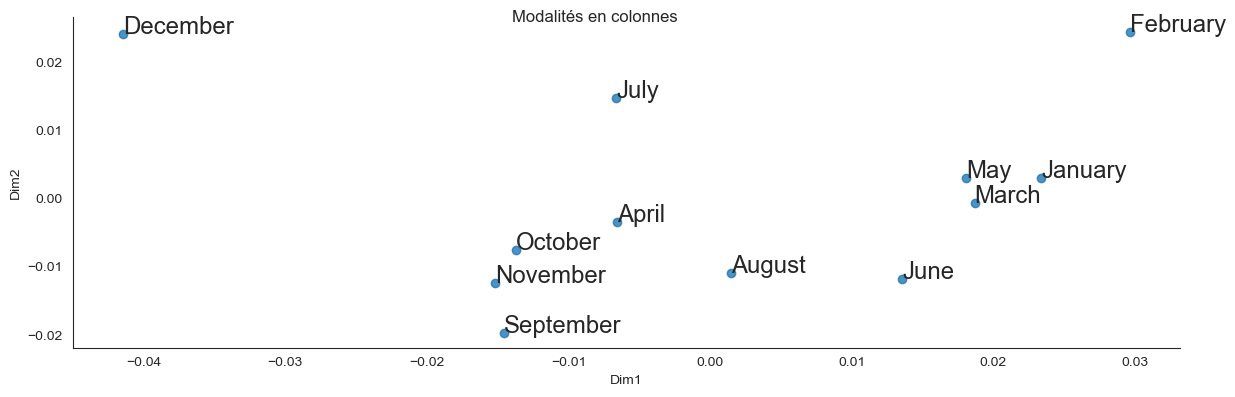

In [12]:
g_col = seaborn.lmplot(x = "Dim1", y = "Dim2", data = df_col, fit_reg = False, 
                       height = 4, aspect = 3)
g_col.fig.suptitle("Modalités en colonnes")
for i in df_col.index:
    plt.text(df_col.loc[i].Dim1, df_col.loc[i].Dim2, i, size = "xx-large")
plt.show()

## Représentation simultanée

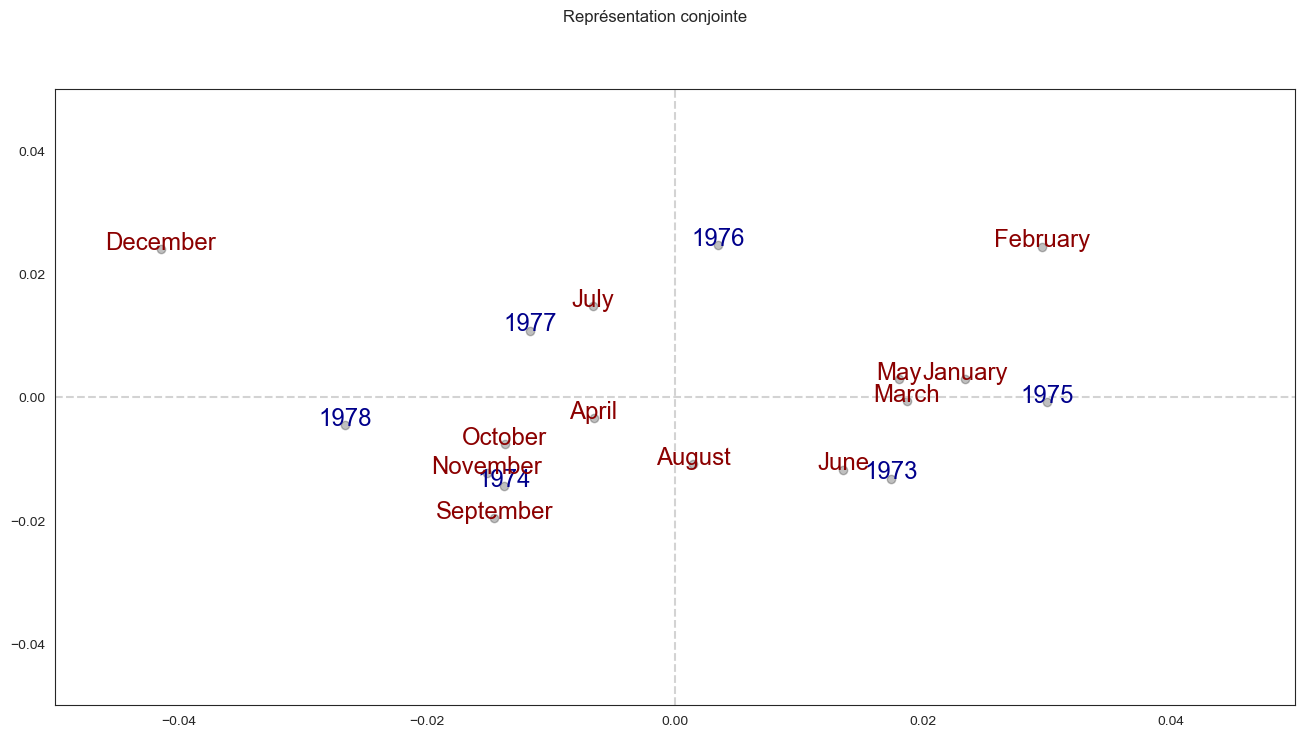

In [13]:
fig = plt.figure(figsize = (16,8))
plt.xlim(-.05, .05)
plt.ylim(-.05, .05)

plt.axhline(y=0, color = "lightgray", linestyle = "dashed")
plt.axvline(x=0, color = "lightgray", linestyle = "dashed")

for i in df_row.index:
    plt.scatter(df_row.loc[i].Dim1, df_row.loc[i].Dim2, alpha = .25, c = "black")
    plt.text(df_row.loc[i].Dim1, df_row.loc[i].Dim2, i, size = "xx-large", color = "darkblue", ha = "center")

for i in df_col.index:
    plt.scatter(df_col.loc[i].Dim1, df_col.loc[i].Dim2, alpha = .25, c = "black")
    plt.text(df_col.loc[i].Dim1, df_col.loc[i].Dim2, i, size = "xx-large", color = "darkred", ha = "center")

fig.suptitle("Représentation conjointe")
plt.show()

## Importance de chaque modalité

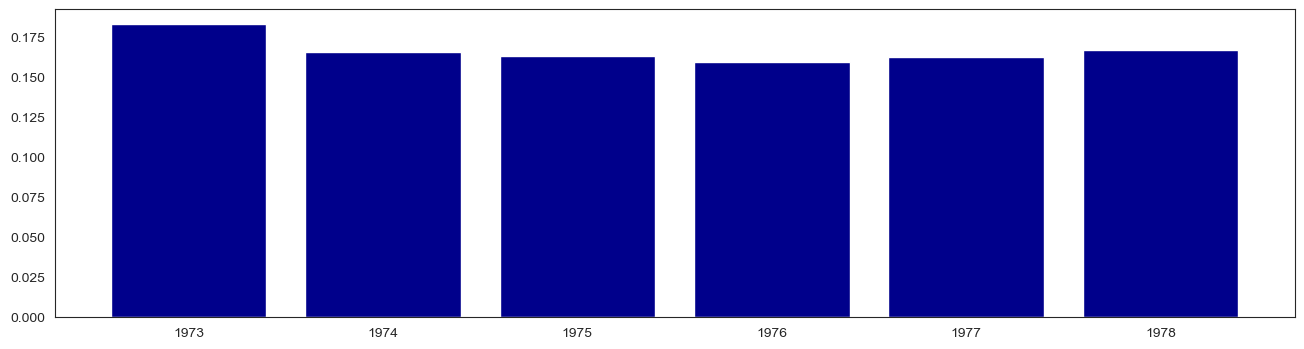

In [14]:
plt.figure(figsize = (16, 4))
plt.bar(df.index, ca.row_masses_, color = "darkblue")
plt.show()

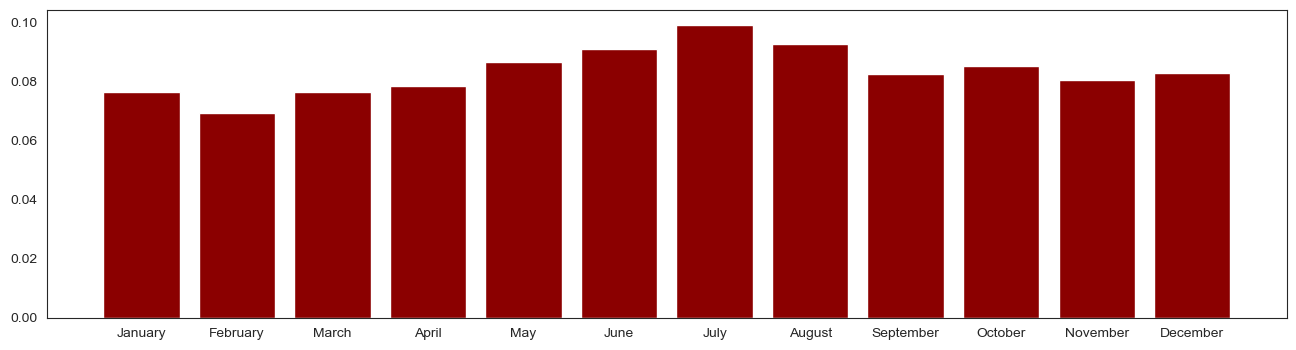

In [15]:
plt.figure(figsize = (16, 4))
plt.bar(df.columns, ca.col_masses_, color = "darkred")
plt.show()

## AFC - Profils lignes

In [16]:
p_row = df.div(df.sum(axis=1), axis=0).round(4) * 100
p_row

Month,January,February,March,April,May,June,July,August,September,October,November,December
Year,,,,,,,,,,,,
1973,7.78,7.00,7.71,7.89,8.65,9.35,9.77,9.28,8.39,8.58,7.91,7.71
1974,7.41,6.67,7.68,8.05,8.33,9.09,9.67,9.39,8.36,8.73,8.33,8.30
1975,7.92,7.09,7.88,7.64,9.11,9.27,9.79,9.33,8.04,8.21,7.92,7.80
1976,7.66,7.41,7.71,7.87,8.56,8.88,10.00,9.11,7.98,8.43,7.82,8.58
1977,7.57,6.76,7.51,7.88,8.64,9.03,10.32,9.04,8.08,8.60,8.03,8.55
1978,7.42,6.53,7.38,7.76,8.63,8.93,9.93,9.30,8.62,8.59,8.17,8.75


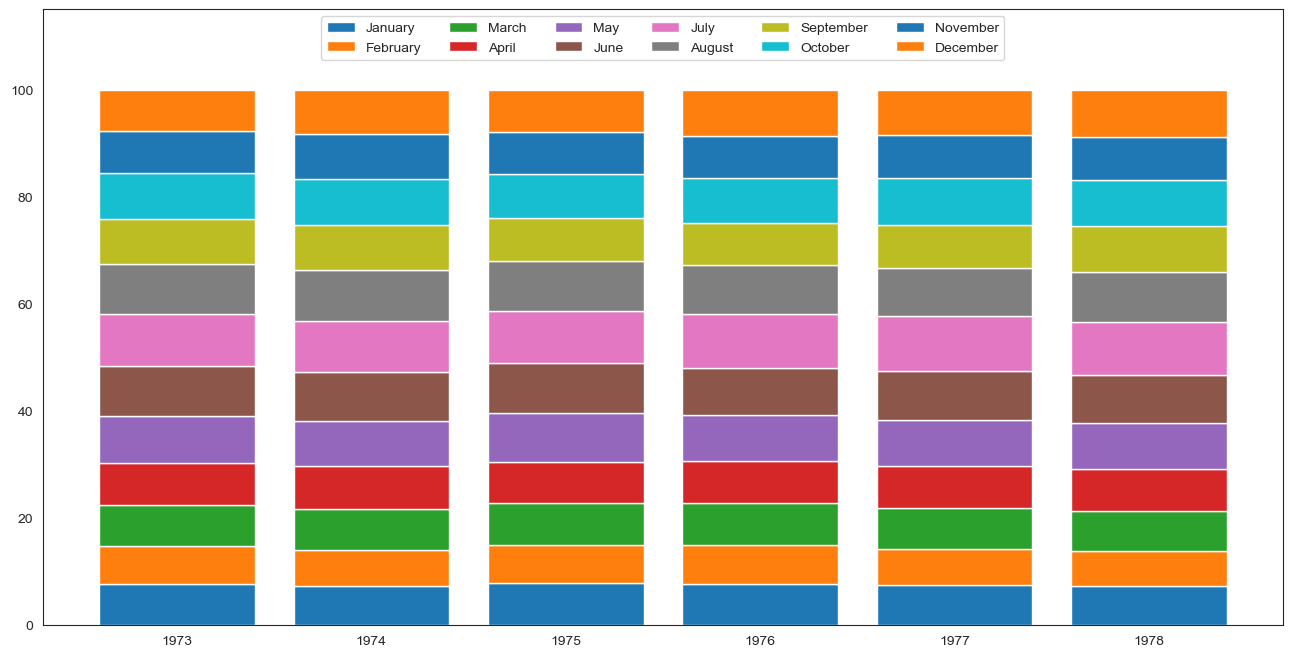

In [17]:
fig = plt.figure(figsize = (16, 8))
base = numpy.zeros(6)
for m in p_row.columns:
    plt.bar(p_row.index, p_row[m], bottom = base, label = m)
    base = base + p_row[m]
plt.margins(0.05, 0.15)
plt.legend(ncol = 6, loc = 9)
plt.show()

## AFC - Profils colonnes


In [18]:
p_col = df.div(df.sum(axis=0), axis=1).round(4) * 100
p_col

Month,January,February,March,April,May,June,July,August,September,October,November,December
Year,,,,,,,,,,,,
1973,18.66,18.55,18.46,18.40,18.30,18.80,18.04,18.37,18.61,18.42,18.03,17.06
1974,16.06,15.97,16.62,16.96,15.92,16.52,16.14,16.79,16.75,16.92,17.14,16.59
1975,16.91,16.72,16.79,15.85,17.15,16.60,16.09,16.45,15.87,15.69,16.06,15.35
1976,15.99,17.07,16.06,15.96,15.75,15.54,16.07,15.69,15.40,15.74,15.50,16.53
1977,16.14,15.92,15.97,16.33,16.24,16.15,16.94,15.90,15.93,16.41,16.27,16.81
1978,16.24,15.77,16.11,16.50,16.65,16.39,16.72,16.80,17.45,16.81,16.99,17.66


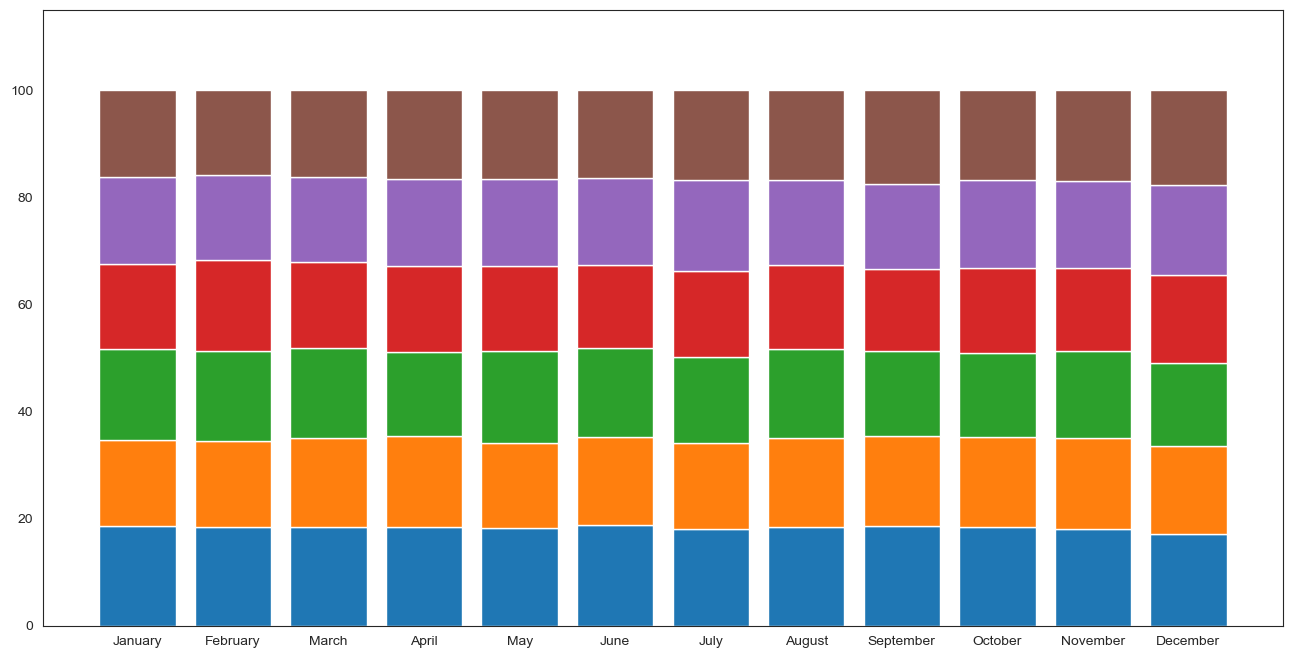

In [19]:
fig = plt.figure(figsize = (16, 8))
base = numpy.zeros(12)
for m in p_col.index:
    plt.bar(p_col.columns, p_col.loc[m], bottom = base, label = m)
    base = base + p_col.loc[m]
plt.margins(0.05, 0.15)
#plt.legend(ncol = 6, loc = 9) # NE FONCTIONNE PAS CHEZ MOI ACTUELLEMENT...
plt.show()

## Catégories socio-professionnelles dans les régions française

Nous disposons sur cette [page](https://www.insee.fr/fr/statistiques/1893185) de la répartition de la population active de 25 à 54 ans selon la catégorie socioprofessionnelle et la position vis à vis de l’emploi, par commune et département (de 1968 à 2014). 

Les codes ci-dessous vous montrent comment les importer.

In [20]:
import pandas

regions1968 = pandas.read_csv("https://fxjollois.github.io/donnees/regions-csp/regions-csp-1968.csv",
                              index_col = "Région")
regions1968.head()

,Agriculteurs Actifs ayant un emploi RP1968,Agriculteurs Chômeurs RP1968,"Artisans, commerçants, chefs d'entreprise Actifs ayant un emploi RP1968","Artisans, commerçants, chefs d'entreprise Chômeurs RP1968",Cadres et professions intellectuelles supérieures Actifs ayant un emploi RP1968,Cadres et professions intellectuelles supérieures Chômeurs RP1968,Professions intermédiaires Actifs ayant un emploi RP1968,Professions intermédiaires Chômeurs RP1968,Employés Actifs ayant un emploi RP1968,Employés Chômeurs RP1968,Ouvriers Actifs ayant un emploi RP1968,Ouvriers Chômeurs RP1968
Région,,,,,,,,,,,,
Île-de-France,13652,0,221520,12,305912,4212,521652,7328,791704,20832,879892,34556
Centre-Val de Loire,73128,0,53572,0,21604,144,59452,616,85424,1904,183304,3748
Bourgogne-Franche-Comté,85284,0,61824,0,26604,84,76732,432,103348,1412,231496,3076
Normandie,113008,0,69388,0,30088,144,86712,556,113204,2148,256920,5376
Hauts-de-France,86004,0,119944,0,53872,312,160128,1052,197596,3532,541364,13664


In [21]:
regions2014 = pandas.read_csv("https://fxjollois.github.io/donnees/regions-csp/regions-csp-2014.csv",
                              index_col = "Région")
regions2014.head()

,Agriculteurs Actifs ayant un emploi RP2014,Agriculteurs Chômeurs RP2014,"Artisans, commerçants, chefs d'entreprise Actifs ayant un emploi RP2014","Artisans, commerçants, chefs d'entreprise Chômeurs RP2014",Cadres et professions intellectuelles supérieures Actifs ayant un emploi RP2014,Cadres et professions intellectuelles supérieures Chômeurs RP2014,Professions intermédiaires Actifs ayant un emploi RP2014,Professions intermédiaires Chômeurs RP2014,Employés Actifs ayant un emploi RP2014,Employés Chômeurs RP2014,Ouvriers Actifs ayant un emploi RP2014,Ouvriers Chômeurs RP2014
Région,,,,,,,,,,,,
Île-de-France,3373.297125,195.053895,203747.801541,17112.882402,1.287917e+06,61943.340704,1.095707e+06,120136.339854,1.017211e+06,171489.384828,521635.119285,112144.255513
Centre-Val de Loire,13731.136316,164.913387,47577.256270,3168.849596,1.087993e+05,4139.710087,2.100894e+05,16730.919522,2.187664e+05,32895.248697,184516.579228,36237.921528
Bourgogne-Franche-Comté,20314.763142,177.683361,53729.925925,3471.206196,1.053460e+05,3894.747983,2.218569e+05,17036.689778,2.271630e+05,34036.105976,219598.002062,42277.992665
Normandie,19265.892020,162.360831,61807.703240,4309.923695,1.257314e+05,4575.836184,2.655183e+05,21068.120831,2.796448e+05,47312.820231,250432.208276,50014.556203
Hauts-de-France,17767.070961,184.594238,87398.160828,8462.259655,2.480851e+05,9086.003241,4.721263e+05,42533.984972,4.992887e+05,98340.151953,436388.567456,118181.606481


### Travail à faire

- Réaliser une AFC sur le croisement entre la catégorie socioprofessionnelle et la région
    - pour 1968
    - pour 2014
- A l’aide des outils à votre disposition (tableaux et graphiques),
    - Décrire la situation pour chaque année,
    - Comparer les deux situations